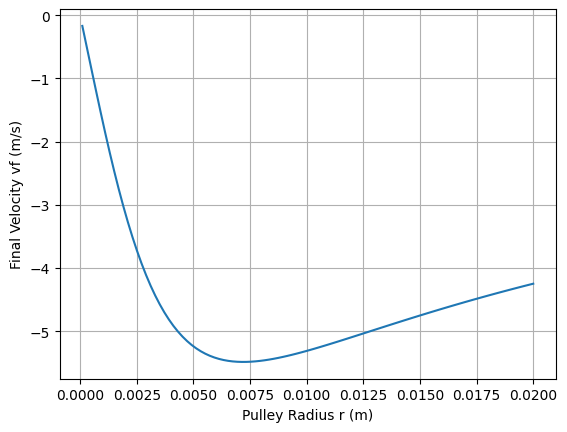

In [1]:
import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# System Parameters
r = 0.006 #pulley radius
tau_max = 0.2795 #Nm
w_max = 1704 #rad/s
m = 0.100 #kg
I = 0.5 * (37.4/1000/2) * (28.4/1000/2)**2 #kg m^2
g = 9.81 #m/s^2
# g = 0 #m/s^2

s = -0.08 #stroke length


r = np.linspace(0.0001, 0.020, 100)
G = -1/r
a = (G*tau_max + m*g)/(m + I*G**2) #acceleration constant
b = (G**2 * tau_max/w_max)/(m + I*G**2)   #backemf constant
# ODE is dv/dt = a - bv

vf = (a / b) * (1 + np.real(lambertw(-np.exp(-(1 + (b**2 * s) / a)))))

plt.plot(r, vf)
# plt.axvline(x=np.sqrt(I/m)*1000, color='r', linestyle='--', label='Theoretical Optimum')

plt.xlabel('Pulley Radius r (m)')
plt.ylabel('Final Velocity vf (m/s)')

plt.grid(True)

In [2]:
import casadi as ca


guess = [0.180, 0.001, 0.02] # L, r, T
params = [
    0.120, # stroke
    0.1,  # m
    0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia (cylinder approx. mass=half of 37.4g, diameter 28.4mm)
    0.2795,  # tau_max
    1704,  # w_max
    9.81, # g
    0.160, # y0
]
# axs[1,0].axhline(params[4]/2, color='k', linestyle=':')

def optimize_tsa(params, guess):
    stroke = params[0] # leg stroke length
    m = params[1] # load mass
    I = params[2] # rotor inertia
    tau_max = params[3] # motor stall torque
    w_max = params[4] # motor free speed
    g = params[5] # gravity
    y0 = params[6]

    state = ca.MX.sym('y', 2)
    L = ca.MX.sym('L')
    r = ca.MX.sym('r')
    # y0 = ca.MX.sym('y0')
    T = ca.MX.sym('T')

    y = state[0]
    yd = state[1]

    discriminant = ca.fmax(L**2 - y**2, 0) 
    sqrt_term = ca.sqrt(discriminant)
    G = -y / (r * sqrt_term)
    dG_dt = - (L**2) / (r * (sqrt_term**3)) * yd

    ydd = (G * tau_max*(1 - G*yd/w_max) + m*g - (I * G * dG_dt * yd)) / (m + I*G**2) #negative
    ode = ca.vertcat(
        T*yd,
        T*ydd
    )

    dae = {'x': state, 'p': ca.vertcat(L, r, T), 'ode': ode}
    integrator = ca.integrator('F', 'rk', dae, {'tf': 1.0})

    opti = ca.Opti()
    global L_var, r_var, T_var
    L_var = opti.variable()
    r_var = opti.variable()
    T_var = opti.variable()
    initial_state = ca.vertcat(y0, 0)
    res = integrator(x0=initial_state, p=ca.vertcat(L_var, r_var, T_var))
    y_final = res['xf'][0]
    yd_final = res['xf'][1]

    opti.minimize(yd_final)

    opti.subject_to(L_var > y0 + 0.001)
    opti.subject_to(L_var < 10)
    opti.subject_to(r_var > 0.0001)
    opti.subject_to(r_var < 0.100)
    opti.subject_to(y_final > y0 - stroke)
    # opti.subject_to(y_final < y0)
    # opti.subject_to(y_final > 0)

    opti.subject_to(T_var > 0)
    # opti.subject_to(T_var <= 2.0)

    # Set some initial guesses for the solver
    vars_list = [L_var, r_var, T_var]
    for var, guess in zip(vars_list, guess):
        opti.set_initial(var, guess)

    # Solve
    opts = {'ipopt.print_level': 0, 'print_time': 0}
    opti.solver('ipopt', opts)
    sol = opti.solve()

    variables = []
    for i,varname in enumerate([L_var, r_var, T_var, y_final, yd_final]):
        variables.append(sol.value(varname))
    return variables

for m_val in np.linspace(0.050, 0.50, 20):
    params[1] = 0.5
    variables = optimize_tsa(params, guess)

labels = ['L_var', 'r_var', 'T_var', 'y_final', 'yd_final']
print("{:<10} {:<10} {:<10} {:<12} {:<12}".format(*labels))
print("{:<10.6f} {:<10.6f} {:<10.6f} {:<12.6f} {:<12.6f}".format(*variables))
vf = variables[4]
mass = params[1]
height = foot_mass_ratio = 0.2
total_mass = mass + foot_mass_ratio*mass
takeoff_vel = vf * mass/total_mass
height = 0.5*takeoff_vel**2 / g
print(f'height: {height:.3f} m')

CasADi - 2026-01-09 19:16:23 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:521]



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

L_var      r_var      T_var      y_final      yd_final    
0.161000   0.002492   0.056987   0.040000     -4.463608   
height: 0.705 m


In [3]:
DT = 0.00001

from scipy.integrate import solve_ivp
''' IDEAL '''
def dynamics(t, states, params):
    y = states[0] # output linear position (always positive, string base is 0)
    yd = states[1] # output linear velocity (negative)

    stroke = params[0] # leg stroke length
    m = params[1] # load mass
    I = params[2] # rotor inertia
    tau_max = params[3] # motor stall torque
    w_max = params[4] # motor free speed
    g = params[5] # gravity

    P_max = (tau_max * w_max) / 4

    if yd > 1e-6:
        ydd = (P_max/yd - m*g) / m
    else:
        ydd = 1/1e-6

    return [yd, ydd]


def num_integration(params):

    stroke = params[0] # leg stroke length

    def stroke_end_event(t, x):
        y, yd = x
        return y - stroke
    stroke_end_event.terminal = True
    stroke_end_event.direction = 0 #triggers if went from postive to negative
    
    initial_state = [0, 0]
    end_time = 1
    t_eval = np.arange(0, end_time, DT)
    sol = solve_ivp(
        lambda t, states: dynamics(t, states, params), 
        [0, end_time], 
        initial_state, 
        events=stroke_end_event, 
        t_eval=t_eval, 
        max_step=DT,
        method='RK45', 
        vectorized=False
    )

    # sol.t may be shorter than t_eval if the event was triggered
    return sol.t, sol.y[0], sol.y[1]

params = [
    0.080, # stroke
    0.050,  # m
    I, # I rotor inertia
    tau_max,  # tau_max
    w_max,  # w_max
    g, # g
]
t, y, yd = num_integration(params)
P_max = (tau_max * w_max) / 4
# plt.plot(t, yd, label='actual')
# plt.plot(t, np.sqrt(2*P_max/params[1] * t), label='no gravity')
# plt.legend()
# plt.show()

# plt.figure()
# plt.plot(t, y)

In [13]:
import numpy as np
from scipy.special import lambertw
from scipy.optimize import minimize_scalar, brentq
import matplotlib.pyplot as plt
%matplotlib widget

# --- System Parameters ---
tau_max = 0.2795 
w_max = 1704 
g = 9.81 
# g = 0.01
s_target = -0.080
I = 0.5 * (37.4/1000/2) * (28.4/1000/2)**2 

# Calculate Max Power (Peak of the parabolic power curve)
P_max = (tau_max * w_max) / 4
print(f"Peak Motor Power: {P_max:.2f} Watts")

def get_vf_pulley(r_val, m_val):
    if r_val <= 1e-6: return 0.0
    G = -1/r_val
    m_eff = m_val + I * G**2
    a = (G * tau_max + m_val * g) / m_eff
    b = (G**2 * tau_max / w_max) / m_eff
    if a >= 0: return 0.0 
    arg = -np.exp(-(1 + (b**2 * s_target) / a))
    return (a / b) * (1 + np.real(lambertw(arg)))

# --- 2. Theoretical Constant Power Limit (Exact Integral) ---
def get_vf_max(m_val):
    P = P_max
    s = abs(s_target)

    v_term = P / (m_val * g)  # where P - mgv -> 0+

    def distance_error(v):
        v = abs(v)

        term1 = (P**2 / (m_val**2 * g**3)) * np.log(P / (P - m_val * g * v))
        term2 = (P * v) / (m_val * g**2)
        term3 = (v**2) / (2 * g)

        return (term1 - term2 - term3) - s

    # This *should* bracket now
    v_solution = brentq(distance_error, 1e-12, 0.999 * v_term)
    return -v_solution


# --- Generate Data ---
masses = np.linspace(0.050, 0.50, 18)
pulley_vels = []
max_vels = []
max_vels2 = []
tsa_vels = []
for m in masses:
# for m in [0.1]:
    # pulley with optimal radius
    r_crit = tau_max / (m * g)
    res = minimize_scalar(lambda r: get_vf_pulley(r, m), bounds=(0, r_crit), method='bounded')
    print(f"Pulley: m={m*1000:.0f}g I={I*1e6:.2f}e-06 r={res.x*1000:.2f}mm vf={abs(res.fun):.2f}m/s") 
    pulley_vels.append(abs(res.fun))


    params = [
        abs(s_target), # stroke
        m,  # m
        I, # I rotor inertia
        tau_max,  # tau_max
        w_max,  # w_max
        g, # g
        0.160, # y0
    ]

    # theoretical Limit
    max_vels.append(abs(get_vf_max(m)))
    t,y,yd = num_integration(params)
    max_vels2.append(max(yd))

    # tsa
    try:
        guess = [0.180, 0.001, 0.02] # L, r, T
        variables = optimize_tsa(params, guess)
        tsa_vels.append(-variables[4])
    except Exception as e:
        print(f"Error optimizing TSA for mass {m}: {e}")
        tsa_vels.append(0)

foot_mass_ratio = 0.2
total_mass = masses + foot_mass_ratio*masses
max_takeoff_vel = max_vels * masses/total_mass
max_takeoff_vel2 = max_vels2 * masses/total_mass
pulley_takeoff_vel = pulley_vels * masses/total_mass
tsa_takeoff_vel = tsa_vels * masses/total_mass

max_height = 0.5*np.array(max_takeoff_vel)**2 / g
max_height2 = 0.5*np.array(max_takeoff_vel2)**2 / g
pulley_height = 0.5*np.array(pulley_takeoff_vel)**2 / g
tsa_height = 0.5*np.array(tsa_takeoff_vel)**2 / g

# plt.figure(figsize=(10, 6))
# plt.plot(masses, max_height, 'r--', linewidth=2, label=f'Constant power implicit P={P_max:.1f}W')
# plt.plot(masses, max_height2, 'y--', linewidth=3, label=f'Constant power solve_ivp P={P_max:.1f}W')
# plt.plot(masses, pulley_height, 'blue', linewidth=2, label=f'Optimal Pulley')
# plt.plot(masses, tsa_height, 'green', linewidth=2, label=f'TSA')
# plt.axhline(y=0, color='k', linestyle='--')
# plt.xlabel('Mass (kg)')
# plt.ylabel('height (m)')
# plt.legend()
# plt.grid()

Peak Motor Power: 119.07 Watts
Pulley: m=50g I=1.89e-06 r=9.58mm vf=6.78m/s
Pulley: m=76g I=1.89e-06 r=8.04mm vf=5.96m/s
Pulley: m=103g I=1.89e-06 r=7.12mm vf=5.44m/s
Pulley: m=129g I=1.89e-06 r=6.49mm vf=5.07m/s
Pulley: m=156g I=1.89e-06 r=6.02mm vf=4.78m/s
Pulley: m=182g I=1.89e-06 r=5.65mm vf=4.55m/s
Pulley: m=209g I=1.89e-06 r=5.34mm vf=4.36m/s
Pulley: m=235g I=1.89e-06 r=5.09mm vf=4.19m/s
Pulley: m=262g I=1.89e-06 r=4.88mm vf=4.05m/s
Pulley: m=288g I=1.89e-06 r=4.69mm vf=3.93m/s
Pulley: m=315g I=1.89e-06 r=4.53mm vf=3.82m/s
Pulley: m=341g I=1.89e-06 r=4.38mm vf=3.72m/s
Pulley: m=368g I=1.89e-06 r=4.25mm vf=3.63m/s
Pulley: m=394g I=1.89e-06 r=4.14mm vf=3.54m/s
Pulley: m=421g I=1.89e-06 r=4.03mm vf=3.47m/s
Pulley: m=447g I=1.89e-06 r=3.93mm vf=3.40m/s
Pulley: m=474g I=1.89e-06 r=3.84mm vf=3.33m/s
Pulley: m=500g I=1.89e-06 r=3.76mm vf=3.27m/s


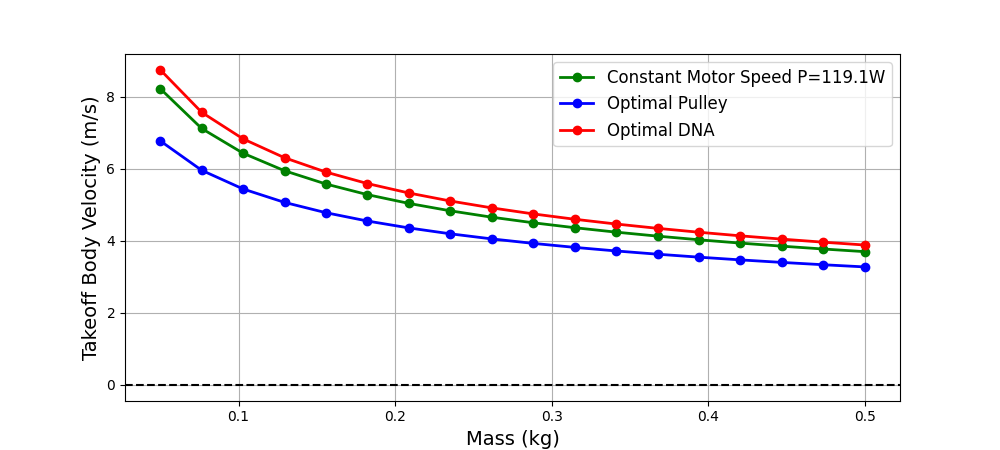

In [18]:
plt.figure(figsize=(10, 4.5))
# plt.plot(masses, max_vels, 'r--', linewidth=2, label=f'Constant power implicit P={P_max:.1f}W')
plt.plot(masses, max_vels2, 'o-', color='green', linewidth=2, label=f'Constant Motor Speed P={P_max:.1f}W')
plt.plot(masses, pulley_vels, 'o-', color='blue', linewidth=2, label=f'Optimal Pulley')
plt.plot(masses, tsa_vels, 'o-', color='red', linewidth=2, label=f'Optimal DNA')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Mass (kg)', fontsize=14)
plt.ylabel('Takeoff Body Velocity (m/s)', fontsize=14)
plt.legend(fontsize=12)
plt.grid()
# plt.ylim(0, 10)

In [5]:
I = 0.5 * (37.4/1000/2) * (28.4/1000/2)**2 
for m in np.arange(0.050, 0.500+1e-6, 0.010):
    r_crit = tau_max / (m * g)
    res = minimize_scalar(lambda r: get_vf_pulley(r, m), bounds=(0, r_crit), method='bounded')
    print(f"Pulley: m={m*1000:.0f}g I={I*1e6:.2f}e-06 r={res.x*1000:.2f}mm vf={abs(res.fun):.2f}m/s") 

Pulley: m=50g I=1.89e-06 r=9.58mm vf=6.78m/s
Pulley: m=60g I=1.89e-06 r=8.88mm vf=6.41m/s
Pulley: m=70g I=1.89e-06 r=8.34mm vf=6.12m/s
Pulley: m=80g I=1.89e-06 r=7.89mm vf=5.88m/s
Pulley: m=90g I=1.89e-06 r=7.52mm vf=5.67m/s
Pulley: m=100g I=1.89e-06 r=7.20mm vf=5.49m/s
Pulley: m=110g I=1.89e-06 r=6.93mm vf=5.33m/s
Pulley: m=120g I=1.89e-06 r=6.69mm vf=5.19m/s
Pulley: m=130g I=1.89e-06 r=6.47mm vf=5.06m/s
Pulley: m=140g I=1.89e-06 r=6.28mm vf=4.94m/s
Pulley: m=150g I=1.89e-06 r=6.11mm vf=4.84m/s
Pulley: m=160g I=1.89e-06 r=5.95mm vf=4.74m/s
Pulley: m=170g I=1.89e-06 r=5.81mm vf=4.65m/s
Pulley: m=180g I=1.89e-06 r=5.68mm vf=4.57m/s
Pulley: m=190g I=1.89e-06 r=5.55mm vf=4.49m/s
Pulley: m=200g I=1.89e-06 r=5.44mm vf=4.42m/s
Pulley: m=210g I=1.89e-06 r=5.33mm vf=4.35m/s
Pulley: m=220g I=1.89e-06 r=5.23mm vf=4.28m/s
Pulley: m=230g I=1.89e-06 r=5.14mm vf=4.22m/s
Pulley: m=240g I=1.89e-06 r=5.05mm vf=4.17m/s
Pulley: m=250g I=1.89e-06 r=4.97mm vf=4.11m/s
Pulley: m=260g I=1.89e-06 r=4.89mm vf=4

In [6]:
voltage = 3
kv=2200
stall_torque_1V = 1/0.045*0.0043 #0.09556 Nm
tau_max = stall_torque_1V*voltage
w_max = kv*voltage*2*np.pi/60
print(f"Voltage: {voltage}V, tau_max: {tau_max:.3f}Nm, w_max: {w_max:.0f}rad/s")
I = 0.9 * (37.4/1000/2) * (28.4/1000/2)**2 
for m in np.arange(0.050, 0.500+1e-6, 0.010):
    r_crit = tau_max / (m * g)
    res = minimize_scalar(lambda r: get_vf_pulley(r, m), bounds=(0, r_crit), method='bounded')
    print(f"Pulley: m={m*1000:.0f}g I={I*1e6:.2f}e-06 r={res.x*1000:.2f}mm vf={abs(res.fun):.2f}m/s") 

Voltage: 3V, tau_max: 0.287Nm, w_max: 691rad/s
Pulley: m=50g I=3.39e-06 r=15.62mm vf=5.35m/s
Pulley: m=60g I=3.39e-06 r=14.54mm vf=5.05m/s
Pulley: m=70g I=3.39e-06 r=13.69mm vf=4.81m/s
Pulley: m=80g I=3.39e-06 r=12.99mm vf=4.60m/s
Pulley: m=90g I=3.39e-06 r=12.41mm vf=4.43m/s
Pulley: m=100g I=3.39e-06 r=11.91mm vf=4.28m/s
Pulley: m=110g I=3.39e-06 r=11.47mm vf=4.15m/s
Pulley: m=120g I=3.39e-06 r=11.09mm vf=4.03m/s
Pulley: m=130g I=3.39e-06 r=10.75mm vf=3.93m/s
Pulley: m=140g I=3.39e-06 r=10.44mm vf=3.83m/s
Pulley: m=150g I=3.39e-06 r=10.17mm vf=3.74m/s
Pulley: m=160g I=3.39e-06 r=9.91mm vf=3.66m/s
Pulley: m=170g I=3.39e-06 r=9.68mm vf=3.59m/s
Pulley: m=180g I=3.39e-06 r=9.47mm vf=3.52m/s
Pulley: m=190g I=3.39e-06 r=9.27mm vf=3.46m/s
Pulley: m=200g I=3.39e-06 r=9.09mm vf=3.40m/s
Pulley: m=210g I=3.39e-06 r=8.91mm vf=3.34m/s
Pulley: m=220g I=3.39e-06 r=8.75mm vf=3.29m/s
Pulley: m=230g I=3.39e-06 r=8.60mm vf=3.24m/s
Pulley: m=240g I=3.39e-06 r=8.46mm vf=3.19m/s
Pulley: m=250g I=3.39e-06 r

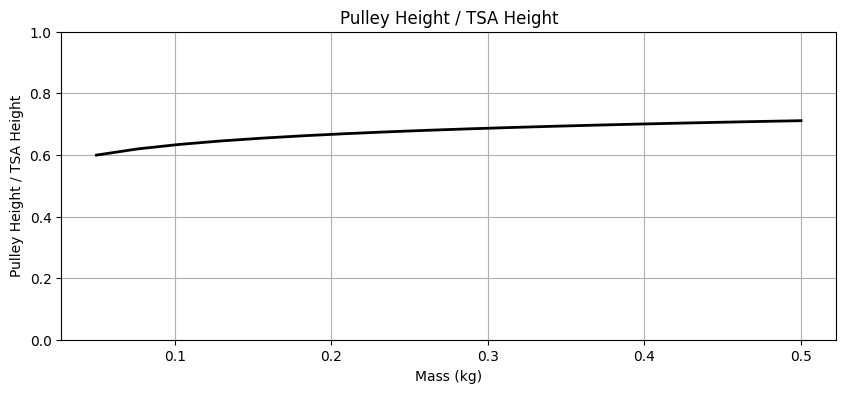

In [7]:
# Plot the ratio of simulated height to theoretical height
plt.figure(figsize=(10, 4))
ratio = np.array(pulley_height) / np.array(tsa_height)
plt.plot(masses, ratio, 'k-', linewidth=2)
plt.xlabel('Mass (kg)')
plt.ylabel('Pulley Height / TSA Height')
plt.title('Pulley Height / TSA Height')
plt.ylim(0, 1)
plt.grid(True)
plt.show()


In [8]:
# DT = 0.00001

# tau_max = 0.2795 #Nm
# w_max = 1704 #rad/s
# m = 0.100 #kg
# I = 0.5 * (37.4/1000/2) * (28.4/1000/2)**2 #kg m^2
# # g = 9.81 #m/s^2
# g = 0 #m/s^2

# def num_integration(y0, stroke, CVT_G_dG_dt):

#     def dynamics(t, states):
#         theta = states[0] # output linear position (always positive, string base is 0)
#         thetad = states[1] # output linear velocity (negative)

#         G, dG_dt = CVT_G_dG_dt(t, theta, thetad)
        
#         ydd = (G * tau_max*(1 - G*yd/w_max) + m*g - (I * G * dG_dt * yd)) / (m + I*G**2)
#         return [yd, ydd]

#     def stroke_end_event(t, x):
#         y, yd = x
#         return y - (y0 - stroke)
#     stroke_end_event.terminal = True
#     stroke_end_event.direction = -1 #triggers if went from postive to negative
    
#     initial_state = [y0-1e-6, 0]
#     end_time = 2
#     t_eval = np.arange(0, end_time, DT)

#     sol = solve_ivp(dynamics, [0, end_time], initial_state, events=stroke_end_event, t_eval=t_eval, method='RK45', vectorized=False)
#     t_num = sol.t
#     y_num = sol.y[0]
#     yd_num = sol.y[1]
#     G, dG_dt = CVT_G_dG_dt(t_num, y_num, yd_num)
#     thetad_num = yd_num*G
#     theta_num = np.cumsum(thetad_num*DT)

#     return t_num, theta_num, thetad_num, y_num, yd_num


# def TSA_G_dG_dt(t, y, yd):
#     L = 0.162
#     r = 0.006
#     sqrt_term = np.sqrt(L**2 - y**2)
#     G = -y / (r * sqrt_term)
#     dG_dt = - (L**2) / (r * (sqrt_term**3)) * yd
#     return G, dG_dt